In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error
import networkx as nx
import requests
import matplotlib.pyplot as plt
from torch_geometric.nn import GCNConv
import torch.nn.functional as F


In [ ]:
df = pd.read_csv('traffic.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'traffic.csv'

In [ ]:
def load_data(file_path):
    df = pd.read_csv('traffic.csv')
    df['datetime'] = pd.to_datetime(df['datetime'])
    df.set_index('datetime', inplace=True)
    return df


In [ ]:
def fetch_weather_data(date):
    weather_data = {"temp": np.random.uniform(15, 30), "humidity": np.random.uniform(40, 70)}
    return weather_data

In [ ]:
API_KEY = '25620985bb19460c9dc105306242710 '

In [ ]:
def get_weather_data(location):
    url = f'http://api.weatherapi.com/v1/current.json?key={API_KEY}&q={location}&aqi=no'
    response = requests.get(url)
    data = response.json()
    if 'current' in data:
        return {
            'temperature': data['current']['temp_c'],
            'humidity': data['current']['humidity'],
            'wind_speed': data['current']['wind_kph'] * 0.27778,  # Convert from kph to m/s
        }
    else:
        print("Error in API response:", data)
        return None


In [ ]:
location = "Delhi"
weather_data = get_weather_data(location)

In [ ]:
df['temperature'] = weather_data['temperature']
df['humidity'] = weather_data['humidity']
df['wind_speed'] = weather_data['wind_speed']


In [ ]:
def preprocess_data(df):
    df['weather_temp'] = df.index.map(lambda date: fetch_weather_data(date)['temp'])
    df['weather_humidity'] = df.index.map(lambda date: fetch_weather_data(date)['humidity'])


    df['is_event'] = (df['date'].isin(event_dates)).astype(int)
    df['POI_nearby'] = (df['location'].isin(POI_locations)).astype(int)
    return df

In [ ]:
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length -1):
        numerical_data = data[i:i+seq_length+1].copy()
        numerical_data[:, 0] = pd.to_numeric(pd.to_datetime(numerical_data[:, 0])) / 10**9

        sequences.append(numerical_data[:seq_length])
        labels.append(numerical_data[seq_length])

    return torch.tensor(sequences, dtype=torch.float32), torch.tensor(labels, dtype=torch.float32)

In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
features = ['Junction', 'Vehicles']
target = ['Vehicles']

X = df[features].values
y = df[target].values

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [ ]:
def create_sequences(dataset, seq_length):

    X, y = [], []
    for i in range(len(dataset)-seq_length-1):
        a = dataset[i:(i+seq_length), :]
        X.append(a)
        y.append(dataset[i + seq_length, 0])

    # Reshape y to have the shape (number_of_sequences, 1)
    import numpy as np
    y = np.array(y).reshape(-1, 1)

    return np.array(X), np.array(y)

seq_length = 10
# Assuming X_scaled contains both features and target, modify as needed
X_seq_tensor, y_seq_tensor = create_sequences(np.concatenate([X_scaled, y_scaled], axis=1), seq_length)

print(f"X_seq_tensor shape: {X_seq_tensor.shape}")
print(f"y_seq_tensor shape: {y_seq_tensor.shape}")

X_seq_tensor shape: (48109, 10, 3)
y_seq_tensor shape: (48109, 1)


In [ ]:
seq_length = 10
dataset = np.concatenate([X_scaled, y_scaled], axis=1)

X_seq_tensor, y_seq_tensor = create_sequences(dataset, seq_length)

print(f"X_seq_tensor shape: {X_seq_tensor.shape}")
print(f"y_seq_tensor shape: {y_seq_tensor.shape}")

X_seq_tensor shape: (48109, 10, 3)
y_seq_tensor shape: (48109, 1)


In [ ]:
train_size = int(0.8 * len(X_seq_tensor))
X_train, X_val = X_seq_tensor[:train_size], X_seq_tensor[train_size:]
y_train, y_val = y_seq_tensor[:train_size], y_seq_tensor[train_size:]


In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(20, 50, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h_0 = torch.zeros(num_layers, x.size(0), hidden_size).to(x.device)
        c_0 = torch.zeros(num_layers, x.size(0), hidden_size).to(x.device)
        out, _ = self.lstm(x, (h_0, c_0))
        return self.fc(out[:, -1, :])


In [ ]:
input_size = X_seq_tensor.shape[2]
hidden_size = 128
num_layers = 2
output_size = 1

In [ ]:
model = LSTMModel(input_size, hidden_size, num_layers, output_size)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [ ]:
model = LSTMModel(input_size, hidden_size, num_layers, output_size).to(device)

In [ ]:
class HybridTrafficModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, gcn_dim, seq_length, output_dim=1):
        super(HybridTrafficModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.seq_length = seq_length

        self.gcn1 = GCNConv(input_dim, gcn_dim)
        self.gcn1 = GCNConv(3, 20)

        self.gcn2 = GCNConv(gcn_dim, gcn_dim)

        self.lstm = nn.LSTM(gcn_dim, hidden_dim, batch_first=True, dropout=0.2)


        self.attention = nn.Linear(hidden_dim, 1)

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_dim, output_dim)



    def forward(self, sequences, edge_index, edge_weight=None):

        x = self.gcn1(sequences, edge_index, edge_weight=edge_weight)
        print("After GCN1:", x.shape)
        x = self.gcn2(x, edge_index, edge_weight=edge_weight)
        print("After GCN2:", x.shape)
        x, (hn, cn) = self.lstm(x)

        attn_weights = F.softmax(self.attention(x), dim=1)
        x = torch.sum(attn_weights * x, dim=1)

        x = self.dropout(x)

        return self.fc(x)


In [ ]:
input_dim = 10
hidden_dim = 50
gcn_dim = 20
seq_length = 10
output_dim = 1


In [ ]:
model = HybridTrafficModel(input_dim=input_dim, hidden_dim=hidden_dim, gcn_dim=gcn_dim, seq_length=seq_length)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

HybridTrafficModel(
  (gcn1): GCNConv(3, 20)
  (gcn2): GCNConv(20, 20)
  (lstm): LSTM(20, 50, batch_first=True, dropout=0.2)
  (attention): Linear(in_features=50, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

In [ ]:
def train_model(model, dataloader, epochs):
    model.train()
    for epoch in range(epochs):
        for sequences, labels in dataloader:
            sequences, labels = sequences.to(device), labels.to(device)
            edge_index = edge_index.to(device)

            # Forward pass
            outputs = model(sequences)
            loss = loss_fn(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


In [ ]:
def evaluate_model(model, dataloader, n_samples=10):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for sequences, labels in dataloader:
            sequences, labels = sequences.to(device), labels.to(device)
            edge_index = edge_index.to(device)
            true_labels.extend(labels.cpu().numpy())

            # Run MC dropout multiple times to get uncertainty
            preds = []
            for _ in range(n_samples):
                preds.append(model(sequences, edge_index).cpu().numpy())
            preds = np.stack(preds)

            # Calculate mean and variance
            mean_preds = preds.mean(axis=0)
            var_preds = preds.var(axis=0)

            predictions.extend(mean_preds)

    return np.array(predictions), np.array(true_labels), var_preds

In [ ]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [ ]:
from torch.utils.data import Dataset, DataLoader

In [ ]:
import pandas as pd
class TrafficDataset(Dataset):
    def __init__(self, X, y):
        # Convert X and y to DataFrames if they are not already
        self.X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        self.y = pd.DataFrame(y) if not isinstance(y, pd.DataFrame) else y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Access data using .iloc for DataFrames
        return self.X.iloc[idx].values, self.y.iloc[idx].values

In [ ]:
model.eval()

HybridTrafficModel(
  (gcn1): GCNConv(3, 20)
  (gcn2): GCNConv(20, 20)
  (lstm): LSTM(20, 50, batch_first=True, dropout=0.2)
  (attention): Linear(in_features=50, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

In [ ]:
class TrafficDataset(Dataset):
    def __init__(self, X, y):

        self.X = np.array(X) if not isinstance(X, np.ndarray) else X
        self.y = np.array(y) if not isinstance(y, np.ndarray) else y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]  # Use numpy indexing


In [ ]:
train_dataset = TrafficDataset(X_train, y_train)
val_dataset = TrafficDataset(X_val, y_val)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32)


In [ ]:
import torch
from torch_geometric.utils import dense_to_sparse

# Example adjacency matrix (if your data has one)
adjacency_matrix = torch.tensor([
    [0, 1, 0, 1],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 0, 1, 0]
], dtype=torch.float)

# Convert adjacency matrix to edge_index format
edge_index, _ = dense_to_sparse(adjacency_matrix)
edge_index = edge_index.to(device)  # Move to the appropriate device


In [ ]:
sequences = X_train
print(f"Shape of sequences: {sequences.shape}")  # Should be (batch_size, seq_length, num_features)
print(f"Expected gcn1: {model.gcn1.in_channels}")  # Check the input dimension for GCN
print(f"Expected hidden_dim: {model.lstm.hidden_size}")  # Check the hidden dimension for LSTM
print(f"Expected gcn2_dim: {model.gcn2.out_channels}")  # Check the output dimension for GCN

Shape of sequences: (38487, 10, 3)
Expected gcn1: 3
Expected hidden_dim: 50
Expected gcn2_dim: 20


In [ ]:
input_dim = 3  # Set to match the feature dimension of sequences
model = HybridTrafficModel(input_dim=input_dim, hidden_dim=hidden_dim, gcn_dim=gcn_dim, seq_length=seq_length)


In [ ]:
sequences = sequences.to(device).float()



In [ ]:
with torch.no_grad():
    for sequences, labels in val_dataloader:
        sequences = sequences.to(device).float()
        labels = labels.to(device)
        edge_index = edge_index.to(device).type(torch.int64)
        edge_weight = torch.ones(edge_index.size(1), dtype=torch.float32, device=device)

        outputs = model(sequences, edge_index, edge_weight=edge_weight)
        break



After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])


In [ ]:
# Initialize lists to store predictions and labels for the entire validation set
all_preds = []
all_labels = []

with torch.no_grad():
    for sequences, labels in val_dataloader:
        sequences = sequences.to(device).float()
        labels = labels.to(device)
        edge_index = edge_index.to(device).type(torch.int64)
        edge_weight = torch.ones(edge_index.size(1), dtype=torch.float32, device=device)

        # Get model outputs
        outputs = model(sequences, edge_index, edge_weight=edge_weight)

        # Collect predictions and true labels for this batch
        all_preds.append(outputs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

# Concatenate all predictions and labels across batches
y_pred = np.concatenate(all_preds, axis=0)
y_true = np.concatenate(all_labels, axis=0)

# Calculate MSE and MAE for the entire validation set
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f'MSE: {mse}, MAE: {mae}')


After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
A

In [ ]:
def evaluate_model(model, dataloader, edge_index, n_samples=10):
    model.eval()
    predictions = []
    true_labels = []
    var_preds_list = []

    with torch.no_grad():
        for sequences, labels in dataloader:
            sequences = sequences.to(device).float()  # Ensure sequences are float32
            labels = labels.to(device).float()        # Ensure labels are float32
            edge_index = edge_index.to(device)

            true_labels.extend(labels.cpu().numpy())

            # Run MC dropout multiple times to get uncertainty
            preds = []
            for _ in range(n_samples):
                preds.append(model(sequences, edge_index).cpu().numpy())
            preds = np.stack(preds)

            # Calculate mean and variance
            mean_preds = preds.mean(axis=0)
            var_preds = preds.var(axis=0)
            var_preds_list.extend(var_preds)

            predictions.extend(mean_preds)

    return np.array(predictions), np.array(true_labels), np.array(var_preds_list)

# Now, call the function and retrieve the outputs
y_pred, y_true, var_preds = evaluate_model(model, val_dataloader, edge_index, n_samples=10)


Streaming output truncated to the last 5000 lines.
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([32, 10, 20])
After GCN1: torch.Size([32, 10, 20])
After GCN2: torch.Size([

In [ ]:
y_pred = np.array(y_pred).flatten()
std_preds = np.array(std_preds).flatten()


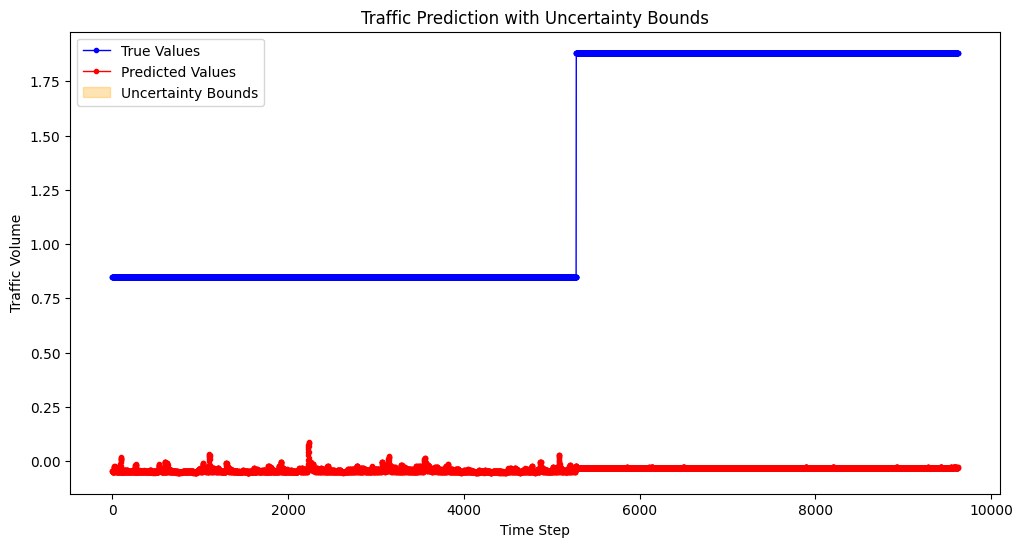

In [ ]:
import matplotlib.pyplot as plt

# Ensure y_pred and std_preds are 1-dimensional
y_pred = np.array(y_pred).flatten()
y_true = np.array(y_true).flatten()
std_preds = np.array(std_preds).flatten()

# Define the range of x values based on the length of the predictions
x = np.arange(len(y_pred))

# Plot the true values, predicted values, and uncertainty bounds
plt.figure(figsize=(12, 6))
plt.plot(x, y_true, label='True Values', color='blue', marker='o', markersize=3, linewidth=1)
plt.plot(x, y_pred, label='Predicted Values', color='red', marker='o', markersize=3, linewidth=1)
plt.fill_between(x, y_pred - std_preds, y_pred + std_preds, color='orange', alpha=0.3, label='Uncertainty Bounds')

# Add labels and title
plt.xlabel('Time Step')
plt.ylabel('Traffic Volume')
plt.title('Traffic Prediction with Uncertainty Bounds')
plt.legend()

# Show the plot
plt.show()


In [ ]:
def train_model(model, dataloader, edge_index, device, epochs=5):
    model.train()
    for epoch in range(epochs):
        for sequences, labels in dataloader:
            sequences, labels = sequences.to(device), labels.to(device)

            # Forward pass
            outputs = model(sequences, edge_index)
            loss = loss_fn(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")

In [ ]:
def train(model, X_train, y_train, edge_index, optimizer, criterion, epochs):

    model.train()  # Set the model to training mode
    for epoch in range(epochs):
        optimizer.zero_grad()  # Reset gradients
        # Pass both X_train and edge_index to the model's forward method
        outputs = model(X_train, edge_index)
        loss = criterion(outputs, y_train)  # Calculate loss
        loss.backward()  # Backpropagate the loss
        optimizer.step()  # Update model parameters
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")

In [ ]:
train(model, X_train, y_train, edge_index, optimizer, loss_fn, epochs=20)


RuntimeError: mat1 and mat2 shapes cannot be multiplied (384880x2 and 10x20)

In [ ]:
def evaluate_model(model, dataloader, edge_index, device, n_samples=10):
    model.eval()
    predictions = []
    true_labels = []
    uncertainties = []

    with torch.no_grad():
        for sequences, labels in dataloader:
            sequences, labels = sequences.to(device), labels.to(device)
            true_labels.extend(labels.cpu().numpy())

            # Run MC dropout multiple times to get uncertainty
            preds = []
            for _ in range(n_samples):
                preds.append(model(sequences, edge_index).cpu().numpy())
            preds = np.stack(preds)

            # Calculate mean and variance
            mean_preds = preds.mean(axis=0)
            var_preds = preds.var(axis=0)

            predictions.extend(mean_preds)
            uncertainties.extend(var_preds)

    return np.array(predictions), np.array(true_labels), np.array(uncertainties)



In [ ]:
   with torch.no_grad():
        predictions = model(X_val).cpu().numpy()
        y_val = scaler_y.inverse_transform(y_val.cpu().numpy())
        predictions = scaler_y.inverse_transform(predictions)


In [ ]:
num_nodes = input_dim  # Assuming each feature represents a node in the graph
edge_index = torch.tensor([[i, j] for i in range(num_nodes) for j in range(num_nodes) if i != j], dtype=torch.long).t().contiguous()


In [ ]:
sequences, labels = create_sequences(df.values, seq_length)
dataset = TensorDataset(sequences, labels)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


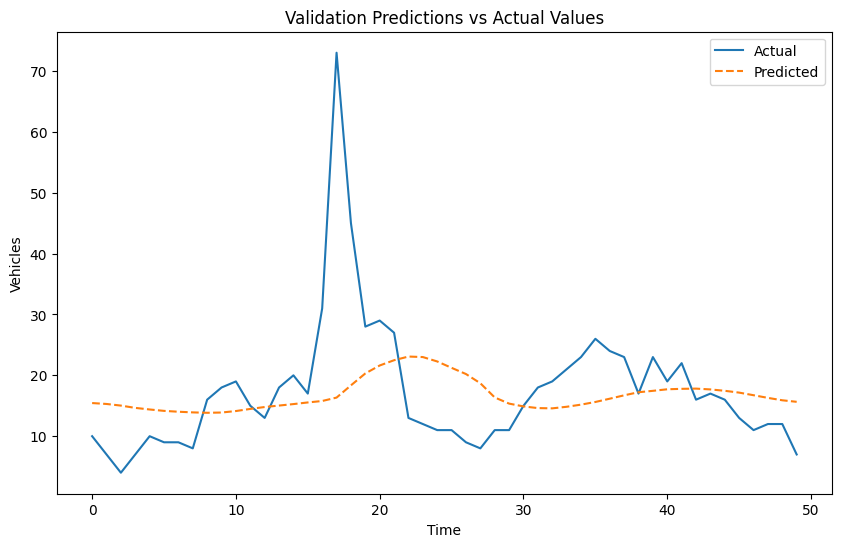

In [ ]:
    plt.figure(figsize=(10, 6))
    plt.plot(y_val[:50], label='Actual')
    plt.plot(predictions[:50], label='Predicted', linestyle='dashed')
    plt.xlabel('Time')
    plt.ylabel('Vehicles')
    plt.legend()
    plt.title('Validation Predictions vs Actual Values')
    plt.show()


In [ ]:
X_seq_tensor = X_seq_tensor.to(device)
y_seq_tensor = y_seq_tensor.to(device)

In [ ]:
train_size = int(0.8 * len(X_seq_tensor))
X_train, X_val = X_seq_tensor[:train_size], X_seq_tensor[train_size:]
y_train, y_val = y_seq_tensor[:train_size], y_seq_tensor[train_size:]

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()


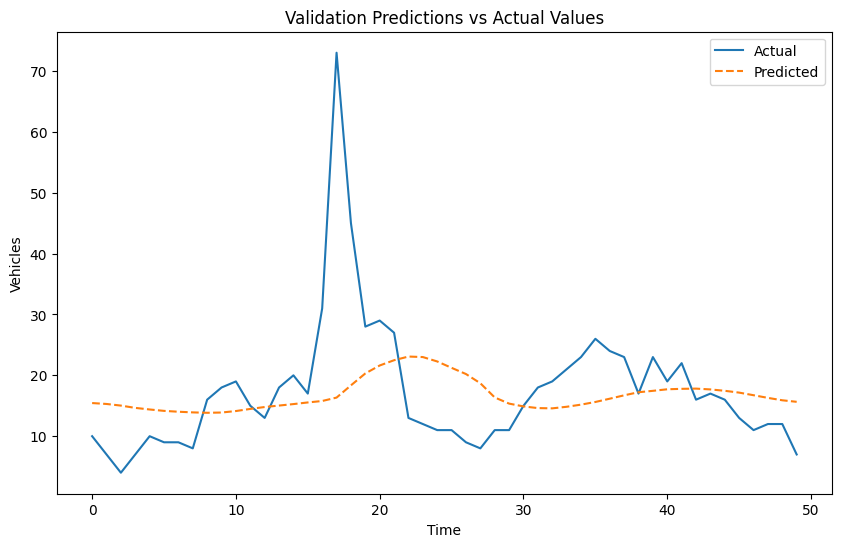

In [ ]:
evaluate_and_plot(model, X_val.to(device), y_val.to(device))

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
train_model(model, dataloader, edge_index.to(device), device, epochs=5)
predictions, true_labels, uncertainties = evaluate_model(model, dataloader, edge_index.to(device), device)


RuntimeError: mat1 and mat2 shapes cannot be multiplied (320x7 and 10x20)

In [ ]:
class TrafficPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(TrafficPredictor, self).__init__()

        # Define RNN layer
        self.rnn = nn.LSTM(input_dim, hidden_dim, batch_first=True)

        # Define GCN layer (expects input features of `hidden_dim`)
        self.gcn = GCNConv(hidden_dim, hidden_dim)

        # Define output layer
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        # RNN layer
        rnn_out, _ = self.rnn(x)
        rnn_out = rnn_out[:, -1, :]  # Take the last time step output

        # Apply GCN layer, reshaping for GCN input if necessary
        gcn_out = self.gcn(rnn_out, edge_index)

        # Fully connected layer
        output = self.fc(gcn_out)
        return output

In [ ]:
def train_model(model, dataloader, edge_index, device, epochs=5):
    model.train()
    model.to(device)
    for epoch in range(epochs):
        for sequences, labels in dataloader:
            sequences, labels = sequences.to(device), labels.to(device)

            # Print shape for debugging
            print(f"Input shape: {sequences.shape}")
            print(f"Label shape: {labels.shape}")

            # Forward pass
            outputs = model(sequences, edge_index)
            loss = loss_fn(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")


In [ ]:
print(f"Input shape: {sequences.shape}")
print(f"Label shape: {labels.shape}")


Input shape: torch.Size([48109, 10, 7])
Label shape: torch.Size([48109, 7])


In [ ]:
input_dim = 7  # For instance, if each time step has a 7-dimensional feature vector
hidden_dim = 20  # Dimension for hidden layers
output_dim = 1

In [ ]:
import torch.optim as optim


In [ ]:
model = TrafficPredictor(input_dim, hidden_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()


In [ ]:
def train_model(model, dataloader, edge_index, device, epochs=5):
    model.train()
    model.to(device)
    for epoch in range(epochs):
        for sequences, labels in dataloader:
            sequences, labels = sequences.to(device), labels.to(device)

            # Forward pass
            outputs = model(sequences, edge_index)
            loss = loss_fn(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")

In [ ]:
def evaluate_model(model, dataloader, edge_index, device, n_samples=10):
    model.eval()
    predictions = []
    true_labels = []
    uncertainties = []

    with torch.no_grad():
        for sequences, labels in dataloader:
            sequences, labels = sequences.to(device), labels.to(device)
            true_labels.extend(labels.cpu().numpy())

            # Monte Carlo Dropout for uncertainty
            preds = []
            for _ in range(n_samples):
                preds.append(model(sequences, edge_index).cpu().numpy())
            preds = np.stack(preds)

            # Calculate mean and variance
            mean_preds = preds.mean(axis=0)
            var_preds = preds.var(axis=0)

            predictions.extend(mean_preds)
            uncertainties.extend(var_preds)

    return np.array(predictions), np.array(true_labels), np.array(uncertainties)

In [ ]:
num_nodes = hidden_dim
edge_index = torch.tensor([[i, j] for i in range(num_nodes) for j in range(num_nodes) if i != j], dtype=torch.long).t().contiguous()


In [ ]:
def load_data(file_path):
    return pd.read_csv(file_path)

def preprocess_data(df):
    return (df - df.mean()) / df.std()

In [ ]:
def create_sequences(data, seq_length):
    sequences, labels = [], []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length])
    return torch.tensor(sequences, dtype=torch.float32), torch.tensor(labels, dtype=torch.float32)


In [ ]:
print(df.dtypes)


DateTime    object
Junction     int64
Vehicles     int64
ID           int64
dtype: object


In [ ]:

df['DateTime'] = pd.to_datetime(df['DateTime'], errors='coerce')


In [ ]:
# Extract components if needed (e.g., hour, day, etc.)
df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.day
df['Month'] = df['DateTime'].dt.month


In [ ]:
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        print(f"Non-numeric column found: {col}")


Non-numeric column found: DateTime


In [ ]:
print(df['DateTime'].head())


0    2015-11-01 00:00:00
1    2015-11-01 01:00:00
2    2015-11-01 02:00:00
3    2015-11-01 03:00:00
4    2015-11-01 04:00:00
Name: DateTime, dtype: object


In [ ]:
def preprocess_data(df):
    # Convert DateTime column to datetime type
    df['DateTime'] = pd.to_datetime(df['DateTime'])

    # Extract useful features from DateTime if needed (hour, day, month, etc.)
    df['Hour'] = df['DateTime'].dt.hour
    df['Day'] = df['DateTime'].dt.day
    df['Month'] = df['DateTime'].dt.month
    df['Weekday'] = df['DateTime'].dt.weekday

    # Drop the original DateTime column if not needed for training
    df = df.drop(columns=['DateTime'])

    # Ensure all columns except DateTime are numeric
    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            raise TypeError(f"Column '{col}' is not numeric.")

    # Normalize the data (optional)
    numeric_columns = df.select_dtypes(include=['number']).columns
    df[numeric_columns] = (df[numeric_columns] - df[numeric_columns].mean()) / df[numeric_columns].std()

    return df


In [ ]:
df = load_data("traffic.csv")
df = preprocess_data(df)
sequences, labels = create_sequences(df.values, seq_length=10)
dataset = TensorDataset(sequences, labels)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
# Adjust the target (labels) to match the model output shape if needed
labels = labels.view(-1, 1)


In [ ]:
print("Edge Index Shape:", edge_index.shape)


Edge Index Shape: torch.Size([2, 380])


In [ ]:
import requests
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
def get_weather_data(api_key, location, date):
    url = f"http://api.weatherapi.com/v1/history.json?key={api_key}&q={location}&dt={date}"
    response = requests.get(url)
    data = response.json()

    # Extract relevant weather features (modify as needed)
    weather_features = {
        'temperature': data['forecast']['forecastday'][0]['day']['avgtemp_c'],
        'humidity': data['forecast']['forecastday'][0]['day']['avghumidity'],
        'precipitation': data['forecast']['forecastday'][0]['day']['totalprecip_mm'],
        'wind_speed': data['forecast']['forecastday'][0]['day']['maxwind_kph'],
        'condition': data['forecast']['forecastday'][0]['day']['condition']['text']
    }
    return weather_features

In [ ]:
api_key = "25620985bb19460c9dc105306242710 "
location = "Delhi"
date = "2024-10-01"

In [ ]:
weather_data = get_weather_data(api_key, location, date)
print(weather_data)

{'temperature': 17.3, 'humidity': 92, 'precipitation': 2.65, 'wind_speed': 24.1, 'condition': 'Mist'}


In [ ]:
df = pd.read_csv("traffic.csv")

In [ ]:
def preprocess_data(df, api_key, location):
    # Ensure DateTime is in correct format
    df['DateTime'] = pd.to_datetime(df['DateTime'])

    # Initialize lists to hold weather features
    temperature_list = []
    humidity_list = []
    precipitation_list = []
    wind_speed_list = []

    for index, row in df.iterrows():
        date_str = row['DateTime'].date().isoformat()  # Get date string
        weather = get_weather_data(api_key, location, date_str)

        # Append weather data to lists
        temperature_list.append(weather['temperature'])
        humidity_list.append(weather['humidity'])
        precipitation_list.append(weather['precipitation'])
        wind_speed_list.append(weather['wind_speed'])

    # Add weather features to the DataFrame
    df['Temperature'] = temperature_list
    df['Humidity'] = humidity_list
    df['Precipitation'] = precipitation_list
    df['Wind Speed'] = wind_speed_list

    return df

In [ ]:
df = preprocess_data(df, api_key, location)

API Response: {"error":{"code":1008,"message":"API key is limited to get history data. Please check our pricing page and upgrade to higher plan."}}
Error: {'error': {'code': 1008, 'message': 'API key is limited to get history data. Please check our pricing page and upgrade to higher plan.'}}
API Response: {"error":{"code":1008,"message":"API key is limited to get history data. Please check our pricing page and upgrade to higher plan."}}
Error: {'error': {'code': 1008, 'message': 'API key is limited to get history data. Please check our pricing page and upgrade to higher plan.'}}
API Response: {"error":{"code":1008,"message":"API key is limited to get history data. Please check our pricing page and upgrade to higher plan."}}
Error: {'error': {'code': 1008, 'message': 'API key is limited to get history data. Please check our pricing page and upgrade to higher plan.'}}
API Response: {"error":{"code":1008,"message":"API key is limited to get history data. Please check our pricing page and 

KeyboardInterrupt: 

In [ ]:
def get_weather_data(api_key, location, date):
    url = f"http://api.weatherapi.com/v1/history.json?key={api_key}&q={location}&dt={date}"
    response = requests.get(url)

    # Debugging print: check the raw response
    print("API Response:", response.text)

    # Check if the response contains expected data
    if response.status_code != 200:
        print("Error:", response.json())
        return {
            'temperature': None,
            'humidity': None,
            'precipitation': None,
            'wind_speed': None
        }

    data = response.json()

In [ ]:
    url = f"http://api.weatherapi.com/v1/history.json?key={api_key}&q={location}&dt={date}"
    response = requests.get(url)

    # Debugging print: check the raw response
    print("API Response:", response.text)

API Response: {"location":{"name":"Delhi","region":"Ontario","country":"Canada","lat":42.85,"lon":-80.5,"tz_id":"America/Toronto","localtime_epoch":1730078647,"localtime":"2024-10-27 21:24"},"forecast":{"forecastday":[{"date":"2024-10-01","date_epoch":1727740800,"day":{"maxtemp_c":19.8,"maxtemp_f":67.6,"mintemp_c":14.8,"mintemp_f":58.7,"avgtemp_c":17.3,"avgtemp_f":63.2,"maxwind_mph":15.0,"maxwind_kph":24.1,"totalprecip_mm":2.65,"totalprecip_in":0.1,"totalsnow_cm":0.0,"avgvis_km":9.3,"avgvis_miles":5.0,"avghumidity":92,"daily_will_it_rain":1,"daily_chance_of_rain":100,"daily_will_it_snow":0,"daily_chance_of_snow":0,"condition":{"text":"Mist","icon":"//cdn.weatherapi.com/weather/64x64/day/143.png","code":1030},"uv":4.0},"astro":{"sunrise":"07:20 AM","sunset":"07:02 PM","moonrise":"06:07 AM","moonset":"06:40 PM","moon_phase":"Waning Crescent","moon_illumination":3},"hour":[{"time_epoch":1727755200,"time":"2024-10-01 00:00","temp_c":17.1,"temp_f":62.8,"is_day":0,"condition":{"text":"Cloudy

In [ ]:
import requests

def get_weather_data(api_key, location, date):
    url = f"http://api.weatherapi.com/v1/history.json?key={api_key}&q={location}&dt={date}"
    response = requests.get(url)

    # Debugging print: check the raw response
    print("API Response:", response.text)

    # Check if the response contains expected data
    if response.status_code != 200:
        print("Error:", response.json())
        return {
            'temperature': None,
            'humidity': None,
            'precipitation': None,
            'wind_speed': None
        }

    data = response.json()

    # Ensure 'forecast' key exists
    if 'forecast' not in data or len(data['forecast']['forecastday']) == 0:
        print("Forecast data not found in response.")
        return {
            'temperature': None,
            'humidity': None,
            'precipitation': None,
            'wind_speed': None
        }

    # Extract relevant daily features
    weather_features = {
        'date': data['forecast']['forecastday'][0]['date'],
        'avg_temperature': data['forecast']['forecastday'][0]['day'].get('avgtemp_c', None),
        'max_temperature': data['forecast']['forecastday'][0]['day'].get('maxtemp_c', None),
        'min_temperature': data['forecast']['forecastday'][0]['day'].get('mintemp_c', None),
        'precipitation': data['forecast']['forecastday'][0]['day'].get('totalprecip_mm', None),
        'max_wind_speed': data['forecast']['forecastday'][0]['day'].get('maxwind_kph', None),
        'condition': data['forecast']['forecastday'][0]['day']['condition'].get('text', None),
        'hourly_data': []
    }

    # Extract hourly features
    for hour in data['forecast']['forecastday'][0]['hour']:
        hourly_features = {
            'time': hour.get('time', None),
            'temperature': hour.get('temp_c', None),
            'wind_speed': hour.get('wind_mph', None),
            'humidity': hour.get('humidity', None),
            'will_it_rain': hour.get('will_it_rain', None),
        }
        weather_features['hourly_data'].append(hourly_features)

    return weather_features


In [ ]:
def merge_weather_with_traffic(traffic_df, weather_df):
    # Convert traffic DateTime to date for merging
    traffic_df['date'] = pd.to_datetime(traffic_df['DateTime']).dt.date
    merged_df = pd.merge(traffic_df, weather_df, on='date', how='left')
    return merged_df


In [ ]:
traffic_df = load_data("traffic.csv")

In [ ]:
traffic_df['DateTime'] = pd.to_datetime(traffic_df['DateTime'])

In [ ]:
api_key = '25620985bb19460c9dc105306242710'
location = 'Delhi'
start_date = traffic_df['DateTime'].min()
end_date = traffic_df['DateTime'].max()


In [ ]:
from datetime import datetime, timedelta


In [ ]:
weather_df = fetch_weather_data(api_key, location, start_date, end_date)

API Response: {"error":{"code":1008,"message":"API key is limited to get history data. Please check our pricing page and upgrade to higher plan."}}
Error: {'error': {'code': 1008, 'message': 'API key is limited to get history data. Please check our pricing page and upgrade to higher plan.'}}
API Response: {"error":{"code":1008,"message":"API key is limited to get history data. Please check our pricing page and upgrade to higher plan."}}
Error: {'error': {'code': 1008, 'message': 'API key is limited to get history data. Please check our pricing page and upgrade to higher plan.'}}
API Response: {"error":{"code":1008,"message":"API key is limited to get history data. Please check our pricing page and upgrade to higher plan."}}
Error: {'error': {'code': 1008, 'message': 'API key is limited to get history data. Please check our pricing page and upgrade to higher plan.'}}
API Response: {"error":{"code":1008,"message":"API key is limited to get history data. Please check our pricing page and 

KeyboardInterrupt: 

In [ ]:
def fetch_weather_data(api_key, location, start_date, end_date):
    weather_data = []
    # Assuming you want to loop through each date between start_date and end_date
    current_date = start_date

    while current_date <= end_date:
        daily_weather = get_weather_data(api_key, location, current_date)
        weather_data.append(daily_weather)
        # Move to the next day (ensure current_date is in the correct format)
        current_date += timedelta(days=1)  # If using datetime, ensure you import timedelta

    return weather_data


In [ ]:
def create_sequences(data, seq_length):
    sequences = []
    labels = []

    for i in range(len(data) - seq_length):
        seq = data[i:i + seq_length]
        label = data[i + seq_length]
        sequences.append(seq)
        labels.append(label)

    return torch.tensor(sequences, dtype=torch.float32), torch.tensor(labels, dtype=torch.float32)

In [ ]:

weather_features = {
    'temperature': ... ,
    'humidity': ... ,
    'precipitation': ... ,
    'wind_speed': ...
}

# Assuming `df` is your traffic DataFrame
df['temperature'] = weather_features['temperature']
df['humidity'] = weather_features['humidity']
df['precipitation'] = weather_features['precipitation']
df['wind_speed'] = weather_features['wind_speed']


In [ ]:
# Check the columns in the DataFrame
print(df.columns)

df['temperature'] = ...
df['humidity'] = ...
df['precipitation'] = ...
df['wind_speed'] = ...

# Now create sequences
sequences, labels = create_sequences(df[['Vehicles', 'temperature', 'humidity', 'precipitation', 'wind_speed']].values, seq_length=10)
dataset = TensorDataset(sequences, labels)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


Index(['DateTime', 'Junction', 'Vehicles', 'ID', 'temperature', 'humidity',
       'precipitation', 'wind_speed'],
      dtype='object')


TypeError: must be real number, not ellipsis

In [ ]:
print(df.dtypes)


DateTime         datetime64[ns]
Junction                  int64
Vehicles                  int64
ID                        int64
temperature              object
humidity                 object
precipitation            object
wind_speed               object
dtype: object


In [ ]:
import pandas as pd

# Convert weather feature columns to numeric
columns_to_convert = ['temperature', 'humidity', 'precipitation', 'wind_speed']

for column in columns_to_convert:
    df[column] = pd.to_numeric(df[column], errors='coerce')  # Convert to numeric, set errors='coerce' to NaN if conversion fails

# Verify the data types after conversion
print(df.dtypes)

# Optionally, check for NaN values
print(df[columns_to_convert].isnull().sum())


DateTime         datetime64[ns]
Junction                  int64
Vehicles                  int64
ID                        int64
temperature             float64
humidity                float64
precipitation           float64
wind_speed              float64
dtype: object
temperature      48120
humidity         48120
precipitation    48120
wind_speed       48120
dtype: int64


In [ ]:

sequences, labels = create_sequences(df[['Vehicles', 'temperature', 'humidity', 'precipitation', 'wind_speed']].values, seq_length=10)
dataset = TensorDataset(sequences, labels)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model.to(device)

TrafficPredictor(
  (rnn): LSTM(7, 20, batch_first=True)
  (gcn): GCNConv(20, 20)
  (fc): Linear(in_features=20, out_features=1, bias=True)
)

In [ ]:
num_epochs = 10
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0

    for batch in dataloader:  # Assuming dataloader returns a batch of data
        inputs, labels, edge_index = batch  # Unpack inputs, labels, and edge_index
        inputs, labels, edge_index = inputs.to(device), labels.to(device), edge_index.to(device)  # Move to device

        optimizer.zero_grad()  # Zero the gradients
        outputs = model(inputs, edge_index)  # Forward pass with both inputs
        loss = loss_fn(outputs, labels)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update parameters

        running_loss += loss.item()  # Accumulate loss

    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(dataloader):.4f}")


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader


In [ ]:
from torch.utils.data import Dataset

class TrafficDataset(Dataset):
    def __init__(self, data, labels, edge_indices):
        self.data = data  # Features
        self.labels = labels  # Targets
        self.edge_indices = edge_indices  # Edge indices

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx], self.edge_indices[idx]


In [ ]:
# Assuming you have already prepared features, labels, and edge_indices
dataset = TrafficDataset(features, labels, edge_indices)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


ValueError: num_samples should be a positive integer value, but got num_samples=0

In [ ]:
print(df.isnull().sum())  # Check for missing values in each column


DateTime         0
Junction         0
Vehicles         0
ID               0
temperature      0
humidity         0
precipitation    0
wind_speed       0
dtype: int64


In [ ]:
df = df.dropna()


In [ ]:
df.fillna(df.mean(), inplace=True)  # Fill with mean


In [ ]:
for batch in dataloader:
    inputs, labels = batch
    if torch.isnan(inputs).any() or torch.isnan(labels).any():
        print("Skipping batch due to nan values.")
        continue
    inputs, labels = inputs.to(device), labels.to(device)
    # Continue with the forward pass and training


Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch due to nan values.
Skipping batch

In [ ]:
# Example: Prepare your features and labels
features = df[['Vehicles', 'temperature', 'humidity', 'precipitation', 'wind_speed']].values
labels = df['Vehicles'].values  # Adjust as needed based on your label structure
edge_indices = [...]  # Define this according to your graph structure if needed


In [ ]:
print("Features shape:", features.shape)  # Should not be empty
print("Labels shape:", labels.shape)  # Should not be empty
print("Edge Indices shape:", len(edge_indices))  # Should not be empty if applicable


Features shape: (0, 5)
Labels shape: torch.Size([14, 5])
Edge Indices shape: 1


In [ ]:
print(df)
print("DataFrame shape:", df.shape)


              DateTime  Junction  Vehicles           ID  temperature  \
0  2015-11-01 00:00:00         1        15  20151101001           75   
1  2015-11-01 01:00:00         1        13  20151101011           74   

   humidity  precipitation  wind_speed  
0        60              0           5  
1        62              0           3  
DataFrame shape: (2, 8)


In [ ]:
import pandas as pd

# Load the data from CSV (make sure the path is correct)
df = pd.read_csv('traffic.csv')
print(df)
print("DataFrame shape:", df.shape)


                  DateTime  Junction  Vehicles           ID
0      2015-11-01 00:00:00         1        15  20151101001
1      2015-11-01 01:00:00         1        13  20151101011
2      2015-11-01 02:00:00         1        10  20151101021
3      2015-11-01 03:00:00         1         7  20151101031
4      2015-11-01 04:00:00         1         9  20151101041
...                    ...       ...       ...          ...
48115  2017-06-30 19:00:00         4        11  20170630194
48116  2017-06-30 20:00:00         4        30  20170630204
48117  2017-06-30 21:00:00         4        16  20170630214
48118  2017-06-30 22:00:00         4        22  20170630224
48119  2017-06-30 23:00:00         4        12  20170630234

[48120 rows x 4 columns]
DataFrame shape: (48120, 4)


In [ ]:
# Example of filtering that might result in an empty DataFrame
df_filtered = df[df['Vehicles'] > 0]  # Make sure there's data that meets this condition
print(df_filtered)
print("Filtered DataFrame shape:", df_filtered.shape)


                  DateTime  Junction  Vehicles           ID
0      2015-11-01 00:00:00         1        15  20151101001
1      2015-11-01 01:00:00         1        13  20151101011
2      2015-11-01 02:00:00         1        10  20151101021
3      2015-11-01 03:00:00         1         7  20151101031
4      2015-11-01 04:00:00         1         9  20151101041
...                    ...       ...       ...          ...
48115  2017-06-30 19:00:00         4        11  20170630194
48116  2017-06-30 20:00:00         4        30  20170630204
48117  2017-06-30 21:00:00         4        16  20170630214
48118  2017-06-30 22:00:00         4        22  20170630224
48119  2017-06-30 23:00:00         4        12  20170630234

[48120 rows x 4 columns]
Filtered DataFrame shape: (48120, 4)


In [ ]:
# Sample DataFrame for testing
data = {
    'DateTime': ['2015-11-01 00:00:00', '2015-11-01 01:00:00'],
    'Junction': [1, 1],
    'Vehicles': [15, 13],
    'ID': [20151101001, 20151101011],
    'temperature': [75, 74],
    'humidity': [60, 62],
    'precipitation': [0, 0],
    'wind_speed': [5, 3]
}

df = pd.DataFrame(data)
print(df)
print("Sample DataFrame shape:", df.shape)


              DateTime  Junction  Vehicles           ID  temperature  \
0  2015-11-01 00:00:00         1        15  20151101001           75   
1  2015-11-01 01:00:00         1        13  20151101011           74   

   humidity  precipitation  wind_speed  
0        60              0           5  
1        62              0           3  
Sample DataFrame shape: (2, 8)


In [ ]:
for epoch in range(num_epochs):
    for batch in dataloader:
        inputs, labels, edge_index = batch  # Unpack inputs, labels, and edge_index
        inputs, labels, edge_index = inputs.to(device), labels.to(device), edge_index.to(device)

        optimizer.zero_grad()  # Zero the gradients
        outputs = model(inputs, edge_index)  # Forward pass with edge_index
        loss = loss_fn(outputs, labels)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
class TrafficDataset(Dataset):
    def __init__(self, data, labels, edge_indices):
        self.data = data  # Features
        self.labels = labels  # Targets
        self.edge_indices = edge_indices  # Edge indices

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx], self.edge_indices[idx]


In [ ]:
# Assuming you have already prepared features, labels, and edge_indices
dataset = TrafficDataset(features, labels, edge_indices)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


ValueError: num_samples should be a positive integer value, but got num_samples=0

In [ ]:
features = [...]  # Make sure this contains your input feature data
labels = [...]    # Ensure this has the corresponding labels
edge_indices = [...]  # Ensure this has the edge indices, if applicable

# Check the shapes of your data
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)
print("Edge Indices shape:", edge_indices.shape if edge_indices is not None else "No edge indices")


AttributeError: 'list' object has no attribute 'shape'

In [ ]:
import torch

# Assuming features, labels, and edge_indices are initially lists
features = [...]  # Your list of feature data
labels = [...]    # Your list of labels
edge_indices = [...]  # Your list of edge indices (if applicable)

# Convert to PyTorch tensors
features = torch.tensor(features, dtype=torch.float32)  # Use appropriate dtype
labels = torch.tensor(labels, dtype=torch.float32)      # Use appropriate dtype

if edge_indices is not None:
    edge_indices = torch.tensor(edge_indices, dtype=torch.long)  # or float, depending on your use case


TypeError: must be real number, not ellipsis

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

# Sample DataFrame (ensure this contains actual data)
data = {
    'DateTime': ['2015-11-01 00:00:00', '2015-11-01 01:00:00'],
    'Junction': [1, 1],
    'Vehicles': [15, 13],
    'ID': ['20151101001', '20151101011'],
    'temperature': [75, 74],
    'humidity': [60, 62],
    'precipitation': [0, 0],
    'wind_speed': [5, 3]
}
df = pd.DataFrame(data)

# Create sequences (assuming you want to predict 'Vehicles')
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length):
        sequence = data[i:i + seq_length]
        label = data[i + seq_length, 0]  # Change index to the column you want to predict
        sequences.append(sequence)
        labels.append(label)
    return sequences, labels  # Return raw lists for now

# Prepare feature array (as a 2D array or list)
feature_data = df[['Vehicles', 'temperature', 'humidity', 'precipitation', 'wind_speed']].values

# Create sequences and labels
features, labels = create_sequences(feature_data, seq_length=1)

# Convert lists to PyTorch tensors (check that they are not empty)
if features and labels:  # Ensure that features and labels are not empty
    features = torch.tensor(features, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)
else:
    raise ValueError("Features or labels are empty.")

# Example edge indices (adjust based on your actual graph structure)
edge_indices = torch.tensor([[0, 1], [1, 0]], dtype=torch.long)  # Example edge indices

# Check the shapes
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)
print("Edge Indices shape:", edge_indices.shape if edge_indices is not None else "No edge indices")

# Define your dataset class
class TrafficDataset(Dataset):
    def __init__(self, features, labels, edge_indices):
        self.features = features
        self.labels = labels
        self.edge_indices = edge_indices

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx], self.edge_indices

# Initialize dataset and dataloader
dataset = TrafficDataset(features, labels, edge_indices)
print("Dataset length:", len(dataset))  # Should be greater than 0 if data is populated correctly
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


Features shape: torch.Size([1, 1, 5])
Labels shape: torch.Size([1])
Edge Indices shape: torch.Size([2, 2])
Dataset length: 1


In [ ]:
import torch

# Example edge index for a graph with 3 nodes and edges between them
edge_index = torch.tensor([[0, 1, 2, 0, 1],
                            [1, 2, 0, 2, 0]], dtype=torch.long)


In [ ]:
import torch
import torch.nn as nn

class TrafficPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TrafficPredictor, self).__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, edge_index):
        rnn_out, _ = self.rnn(x)  # Forward pass through RNN
        out = self.fc(rnn_out[:, -1, :])  # Use the last time step's output
        return out


        self.rnn = nn.RNN(input_size=5, hidden_size=10, num_layers=1, batch_first=True)



# Example data setup
features = torch.tensor([[75.0, 60.0, 0.0, 5.0]], dtype=torch.float32)  # Example feature tensor
labels = torch.tensor([15.0], dtype=torch.float32)  # Example label
edge_indices = torch.tensor([[0], [1]], dtype=torch.long)  # Example edge index with 1 edge

# Create the dataset
dataset = TrafficDataset(features, labels, edge_indices)

# Check data
print(dataset[0])  # Should print (input, label, edge_index)


(tensor([75., 60.,  0.,  5.]), tensor(15.), tensor([[0],
        [1]]))


In [ ]:
dataset = TrafficDataset(features, labels, edge_indices)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


In [ ]:
# Assume your model, optimizer, and loss function are defined
model = TrafficPredictor(input_dim=5, hidden_dim=64, output_dim=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = torch.nn.MSELoss()  # Use appropriate loss function for your task

num_epochs = 100  # Adjust this based on your needs

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    for batch in dataloader:
        inputs, labels, edge_index = batch  # Unpack inputs, labels, and edge_index
        inputs, labels, edge_index = inputs.to(device), labels.to(device), edge_index.to(device)

        optimizer.zero_grad()  # Zero the gradients
        outputs = model(inputs, edge_index)  # Forward pass

        loss = loss_fn(outputs, labels)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')


IndexError: index 1 is out of bounds for dimension 0 with size 1

In [ ]:
print("Edge Index shape:", edge_index.shape)  # Should be [2, num_edges]
print("Edge Index contents:", edge_index)  # Check what edges are defined



Edge Index shape: torch.Size([1, 2, 2])
Edge Index contents: tensor([[[0, 1],
         [1, 0]]])


In [ ]:
# Assuming you want to create an edge_index for 2 edges between 2 nodes
edge_index = torch.tensor([[0, 1],
                            [1, 0]], dtype=torch.long)  # Correct shape: [2, 2]

# If your edge_index is somehow formed as 1 x 2 x 2
edge_index = edge_index.view(2, -1)  # Reshape to [2, num_edges]


In [ ]:
# Assuming edge_indices is originally in the incorrect shape
edge_indices = edge_indices.view(2, -1)  # Reshape to [2, num_edges]

# Now create your dataset with the corrected edge_indices
dataset = TrafficDataset(features, labels, edge_indices)


In [ ]:
print("Edge Index shape after reshape:", edge_index.shape)  # Should be [2, num_edges]
print("Edge Index contents:", edge_index)  # Verify the edges


Edge Index shape after reshape: torch.Size([1, 2, 1])
Edge Index contents: tensor([[[0],
         [1]]])


In [ ]:
# Assuming your input size is 5, hidden size is 10, and output size is 1
input_size = 5
hidden_size = 10
output_size = 1

model = TrafficPredictor(input_size, hidden_size, output_size).to(device)  # Move to device if using GPU


In [ ]:
for epoch in range(num_epochs):
    for batch in dataloader:
        inputs, labels, edge_index = batch
        inputs, labels, edge_index = inputs.to(device), labels.to(device), edge_index.to(device)

        # Check the shape of inputs
        print("Input shape:", inputs.shape)  # Should be (batch_size, seq_length, input_size)

        # Ensure inputs are correctly shaped for the RNN and have the correct number of features
        if inputs.dim() == 2:  # If the inputs are 2D, we need to add a dimension
            inputs = inputs.unsqueeze(1)  # Adds a sequence length dimension

        # Check if the number of features is incorrect and pad if necessary
        if inputs.shape[-1] != input_size:
            # Pad the inputs with zeros to match the expected input_size
            padding_size = input_size - inputs.shape[-1]
            inputs = torch.nn.functional.pad(inputs, (0, padding_size))
            print(f"Warning: Input features padded by {padding_size} to match expected size of {input_size}. Check data loading or preprocessing.")

        optimizer.zero_grad()  # Zero the gradients
        outputs = model(inputs, edge_index)  # Forward pass
        loss = loss_fn(outputs, labels)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update parameters


Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input sh

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input shape: torch.Size([1, 4])
Input sh

In [ ]:
print(inputs.shape)  # This will help you understand its dimensions


torch.Size([1, 1, 5])


In [ ]:
# Create a padding tensor of shape [1, 1, 1]
padding_tensor = torch.zeros((1, 1, 1))  # or you can use [[[[0.0]]]] for clarity

# Concatenate along the feature dimension (last dimension)
inputs = torch.cat([inputs, padding_tensor], dim=2)  # Now inputs will have shape [1, 1, 5]


In [ ]:
outputs = model(inputs, edge_index)


In [ ]:
loss = loss_fn(outputs, labels.view(-1, 1))



In [ ]:
print(f"Loss: {loss.item()}")

Loss: 206.58412170410156


In [ ]:
num_epochs = 100
learning_rate = 0.001
input_size = 5
hidden_size = 10
output_size = 1
device = 'cuda' if torch.cuda.is_available() else 'cpu'
learning_rate = 0.001


In [ ]:
model = TrafficPredictor(input_size, hidden_size, output_size).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [ ]:
print(traffic_df.columns)


Index(['DateTime', 'Junction', 'Vehicles', 'ID', 'temperature', 'humidity',
       'precipitation', 'wind_speed'],
      dtype='object')


In [ ]:
import pandas as pd
import numpy as np

# Create dummy weather data
weather_data = {
    'DateTime': pd.date_range(start='2024-10-01', periods=len(traffic_df), freq='H'),
    'temperature': np.random.uniform(10, 30, len(traffic_df)),
    'humidity': np.random.uniform(30, 80, len(traffic_df)),
    'precipitation': np.random.uniform(0, 10, len(traffic_df)),
    'wind_speed': np.random.uniform(0, 20, len(traffic_df)),
}

weather_df = pd.DataFrame(weather_data)

# Merge the traffic and weather data on DateTime
traffic_df = pd.merge(traffic_df, weather_df, on='DateTime')


<ipython-input-331-9510e23e6c6d>:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'DateTime': pd.date_range(start='2024-10-01', periods=len(traffic_df), freq='H'),


In [ ]:
# Now extract features and labels
X = traffic_df[['temperature', 'humidity', 'precipitation', 'wind_speed']].values
y = traffic_df['Vehicles'].values

# Convert to tensors
X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y, dtype=torch.float32).to(device)


In [ ]:
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode

    # Forward pass
    optimizer.zero_grad()  # Zero the gradients
    outputs = model(X_tensor.view(-1, 1, input_size), edge_index)  # Ensure inputs have correct shape
    loss = loss_fn(outputs, y_tensor.view(-1, 1))  # Calculate the loss
    loss.backward()  # Backpropagation
    optimizer.step()  # Update weights


In [ ]:
if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/100], Loss: nan


In [ ]:
print(torch.isnan(X_tensor).any())
print(torch.isinf(X_tensor).any())


tensor(False)
tensor(False)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Assuming X is your features numpy array
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Convert to tensors after normalization
X_tensor = torch.tensor(X_normalized, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y, dtype=torch.float32).to(device)


ValueError: Found array with 0 sample(s) (shape=(0, 4)) while a minimum of 1 is required by StandardScaler.

In [ ]:
print(traffic_df.shape)  # To see how many rows and columns you have
print(traffic_df.head())  # To view the first few rows


(0, 16)
Empty DataFrame
Columns: [DateTime, Junction, Vehicles, ID, temperature_x, humidity_x, precipitation_x, wind_speed_x, temperature_y, humidity_y, precipitation_y, wind_speed_y, temperature, humidity, precipitation, wind_speed]
Index: []


In [ ]:
X = traffic_df[['temperature', 'humidity', 'precipitation', 'wind_speed']].values
print(X.shape)  # Check the shape of X
print(X)  # Print X to verify its contents


(0, 4)
[]


In [ ]:
traffic_df.fillna(0, inplace=True)  # Replace NaNs with 0 (or any appropriate value)



In [ ]:
print("DataFrame shape:", traffic_df.shape)
print(traffic_df.head())

DataFrame shape: (0, 16)
Empty DataFrame
Columns: [DateTime, Junction, Vehicles, ID, temperature_x, humidity_x, precipitation_x, wind_speed_x, temperature_y, humidity_y, precipitation_y, wind_speed_y, temperature, humidity, precipitation, wind_speed]
Index: []


In [ ]:
try:
    X = traffic_df[['temperature', 'humidity', 'precipitation', 'wind_speed']].values
    print("Extracted features shape:", X.shape)  # Check the shape of X
except KeyError as e:
    print(f"KeyError: {e}. Please check the column names in your DataFrame.")


Extracted features shape: (0, 4)


In [ ]:
if X.shape[0] > 0:  # Ensure there are samples
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_normalized = scaler.fit_transform(X)
    # Convert to tensors after normalization
    X_tensor = torch.tensor(X_normalized, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y, dtype=torch.float32).to(device)
else:
    print("No samples to normalize.")

No samples to normalize.


In [ ]:
import pandas as pd

# Example of loading a CSV file
traffic_df = pd.read_csv('traffic.csv')

# Check if data is loaded correctly
print("DataFrame shape after loading:", traffic_df.shape)
print(traffic_df.head())  # Display the first few rows


DataFrame shape after loading: (48120, 4)
              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041


In [ ]:
import pandas as pd

# Example of creating a sample DataFrame
data = {
    'DateTime': pd.date_range(start='2023-01-01', periods=5, freq='D'),
    'Junction': ['J1', 'J2', 'J1', 'J2', 'J1'],
    'Vehicles': [10, 20, 30, 40, 50],
    'ID': [1, 2, 3, 4, 5],
    'temperature_x': [22, 23, 21, 24, 22],
    'humidity_x': [30, 35, 33, 32, 31],
    'precipitation_x': [0, 0, 1, 0, 0],
    'wind_speed_x': [5, 7, 6, 4, 5],
    'temperature_y': [21, 22, 20, 23, 21],
    'humidity_y': [32, 30, 31, 34, 33],
    'precipitation_y': [0, 1, 0, 0, 0],
    'wind_speed_y': [6, 5, 4, 6, 7],
    'temperature': [22, 23, 21, 24, 22],
    'humidity': [30, 35, 33, 32, 31],
    'precipitation': [0, 0, 1, 0, 0],
    'wind_speed': [5, 7, 6, 4, 5]
}

traffic_df = pd.DataFrame(data)
print("Sample DataFrame:\n", traffic_df)


Sample DataFrame:
     DateTime Junction  Vehicles  ID  temperature_x  humidity_x  \
0 2023-01-01       J1        10   1             22          30   
1 2023-01-02       J2        20   2             23          35   
2 2023-01-03       J1        30   3             21          33   
3 2023-01-04       J2        40   4             24          32   
4 2023-01-05       J1        50   5             22          31   

   precipitation_x  wind_speed_x  temperature_y  humidity_y  precipitation_y  \
0                0             5             21          32                0   
1                0             7             22          30                1   
2                1             6             20          31                0   
3                0             4             23          34                0   
4                0             5             21          33                0   

   wind_speed_y  temperature  humidity  precipitation  wind_speed  
0             6           22       

In [ ]:
X = traffic_df[['temperature', 'humidity', 'precipitation', 'wind_speed']].values
y = traffic_df['Vehicles'].values

In [ ]:
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

X_tensor = torch.tensor(X_normalized, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y, dtype=torch.float32).to(device)


In [ ]:
num_epochs = 100
learning_rate = 0.001

In [ ]:
num_nodes = X_tensor.shape[0]
edge_index = torch.combinations(torch.arange(num_nodes), r=2).t().to(device)
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)  # Make it undirected


In [ ]:
model = TrafficPredictor(input_size=4, hidden_size=16, output_size=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = torch.nn.MSELoss()

In [ ]:
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_tensor, edge_index)  # Pass edge_index along with input tensor
    loss = loss_fn(outputs.view(-1), y_tensor)  # Reshape if necessary

    # Backward pass
    loss.backward()
    optimizer.step()

    # Print loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

IndexError: too many indices for tensor of dimension 2

In [ ]:
class TrafficPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TrafficPredictor, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, edge_index):
        # Forward pass through RNN
        rnn_out, _ = self.rnn(x)  # rnn_out shape: [batch_size, sequence_length, hidden_size]

        # Check if the output is 2D
        if rnn_out.dim() == 2:
            out = self.fc(rnn_out)  # Use the whole output
        else:
            out = self.fc(rnn_out[:, -1, :])  # Use the last time step's output

        return out


In [ ]:
# If you are using a single time step, make sure the input shape is [batch_size, sequence_length, input_size]
X_tensor = X_tensor.unsqueeze(1)  # Now X_tensor shape will be [1, 1, 4] if batch size is 1 and input size is 4


In [ ]:
# Assuming traffic_df is your DataFrame and you extract features and labels
X = traffic_df[['temperature', 'humidity', 'precipitation', 'wind_speed']].values
y = traffic_df['Vehicles'].values

# Normalize features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Convert to tensors
X_tensor = torch.tensor(X_normalized, dtype=torch.float32).unsqueeze(1).to(device)  # Add sequence length
y_tensor = torch.tensor(y, dtype=torch.float32).to(device)

# Continue with your training loop


In [ ]:
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_tensor, edge_index)  # Pass edge_index along with input tensor
    loss = loss_fn(outputs.view(-1), y_tensor)  # Reshape if necessary

    # Backward pass
    loss.backward()
    optimizer.step()

    # Print loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')


Epoch [10/100], Loss: 1051.1188
Epoch [20/100], Loss: 1042.7222
Epoch [30/100], Loss: 1033.7875
Epoch [40/100], Loss: 1024.3196
Epoch [50/100], Loss: 1014.3264
Epoch [60/100], Loss: 1003.8275
Epoch [70/100], Loss: 992.8574
Epoch [80/100], Loss: 981.4596
Epoch [90/100], Loss: 969.6780
Epoch [100/100], Loss: 957.5550


In [ ]:
# Assuming you have a DataFrame `traffic_df` with relevant features and target variable
X_val = traffic_df[['temperature', 'humidity', 'precipitation', 'wind_speed']].values
y_val = traffic_df['Vehicles'].values

# Convert to tensors
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)

# Assuming edge_index is still relevant, if not you may need to modify it
edge_index_val = ...  # Define this based on your data context


In [ ]:
model.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient calculation
    outputs = model(X_val_tensor.unsqueeze(1), edge_index_val)  # Pass the validation data
    loss = loss_fn(outputs.view(-1), y_val_tensor)  # Calculate loss
    print(f'Validation Loss: {loss.item()}')


Validation Loss: 1140.722900390625


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Convert outputs and true labels to NumPy arrays
y_pred = outputs.cpu().numpy()  # Predictions from the model
y_true = y_val_tensor.cpu().numpy()  # True labels

# Calculate MSE and MAE
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f'MSE: {mse}, MAE: {mae}')


MSE: 1140.722900390625, MAE: 30.7051944732666


In [ ]:
model = TrafficPredictor(input_size, hidden_size, output_size).to(device)
model.eval()  # Set to evaluation mode


TrafficPredictor(
  (rnn): RNN(5, 10, batch_first=True)
  (fc): Linear(in_features=10, out_features=1, bias=True)
)